## CLONING QUASAR
Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.

The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.

In phase 1, SDSS has released photometry data 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST!)

Download the SDSS quasar data

In [5]:
import numpy as np
from matplotlib import pyplot as plt

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats
from tqdm.notebook import tqdm


#The package [astropy](https://www.astropy.org/) 
#contains a ton of useful astro things. For instance, the best-fit cosmological model from the latest Plack data
import astropy
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

In [6]:
#scarichiamo i dati, in particolare prendiamo i dati sulla z (Redshift)
#from urllib.request import urlretrieve
#urlretrieve("http://das.sdss.org/va/qsocat/dr7qso.dat", './dr7qso.dat')
z = np.loadtxt('dr7qso.dat', skiprows = 80, usecols=3) #le prime 80 righe sono "header". Ogni riga della tabella studia un quasar diverso e ogni colonna
#un dato, ovvero 

#colonna 0: nome del quasar
#colonna 1: longitudine
#colonna 2: latitudine
#colonna 3: redshift (z) del quasar, ovvero l'effetto di redshift misurato sulla luce emessa dal quasar.
print("data recovered")

data recovered


- Upsample this distribution in hopefully two ways (but at least one of them), using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

(Hint: It shouldn't. But why?) 

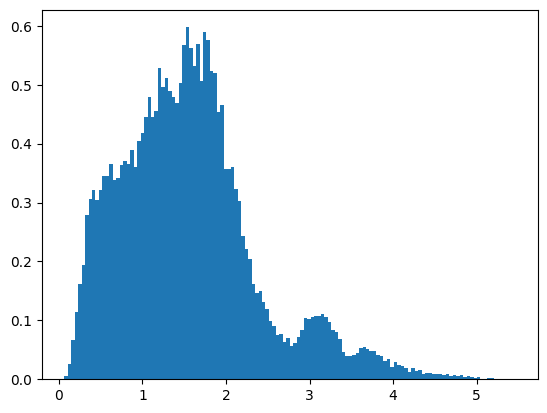

In [7]:
#Visualizziamo la distribuzione dei data samples. Da https://numpy.org/doc/stable/reference/generated/numpy.histogram.html leggiamo come returna i dati la
#funzione

#hist (array): The values of the histogram. 
#bin_edges (array of dtype float): Return the bin edges (length(hist)+1).

pdf_counts, bin_edges, patches = plt.hist(z, density=True, bins = 'auto');

#@Cerchiamo il massimo dell'istogramma in modo da poter scrivere la pdf
pdf_max = np.max(pdf_counts)

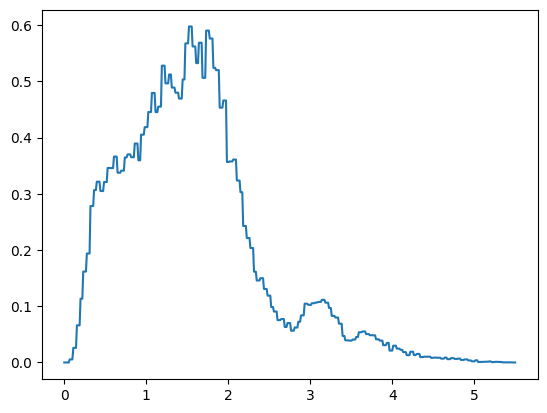

In [8]:
#Definiamo la pdf tramite scipy (per comodità d'uso della cumulativa) 
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_histogram.html

from scipy.stats import rv_histogram
distribution = rv_histogram((pdf_counts, bin_edges))

#ora ne creiamo la pdf
pdf = distribution.pdf

#plottiamo per vedere
x = np.linspace(0, 5.5, 500)
plt.plot(x, pdf(x))

2958
Sono stati creati dati upsampled con una percentuale rispetto a N_Sampled di: 29.580000000000002%


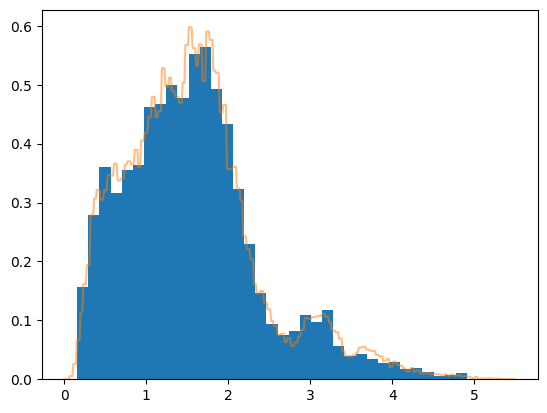

In [9]:
#REJECTION SAMPLING
#Adesso che abbiamo la pdf facciamo upsampling col primo metodo ovvero il rejection sampling
N_sampled = int(1e4)
upsampled_data_rej = []
#La coda della distribuzione si arresta circa a 5, per sicurezza generiamo tra 0 e 5.5
for i in range(N_sampled):
    x_trial = np.random.uniform(0, 5.5)
    y_trial = np.random.uniform(0, pdf_max)

    if( y_trial <= pdf(x_trial) ):
        upsampled_data_rej.append(x_trial)

accepted_rate = (len(upsampled_data_rej)/N_sampled)*100
print(len(upsampled_data_rej))
print(f"Sono stati creati dati upsampled con una percentuale rispetto a N_Sampled di: {accepted_rate}%")

plt.hist(upsampled_data_rej, density = True, bins = 'auto');
plt.plot(x, pdf(x), alpha = 0.5)

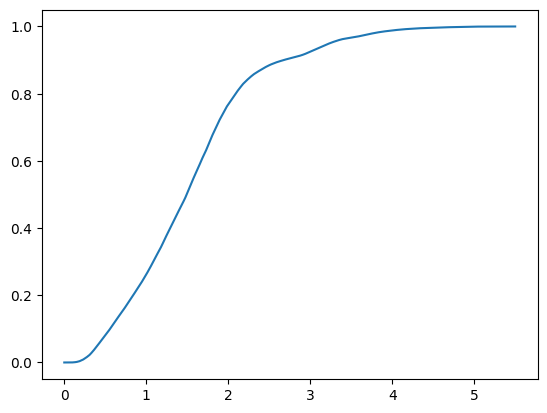

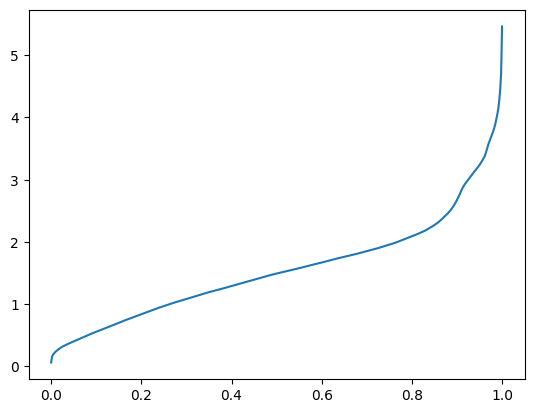

In [10]:
#INVERSE TRANSFORM SAMPLING
#adesso con la pdf in scipy è facile calcolarne la CDF e l'inversa
x = np.linspace(0, 5.5, 500)
cdf = distribution.cdf
plt.plot(x, cdf(x))
plt.show()
#e l'inversa della CDF (la funzione quantile)
quantile = distribution.ppf #Percent point function (inverse of cdf) at q of the given RV.
u = np.linspace(0, 1, 500)
plt.plot(u, quantile(u))
plt.show()

#ora andiamo con l'algoritmo
N_sampled = int(1e4)
upsampled_data_inv = []

for i in range(N_sampled):
    u = np.random.uniform(0,1)

    x = quantile(u)

    upsampled_data_inv.append(x)


10000
Sono stati creati dati upsampled con una percentuale rispetto a N_Sampled di: 100.0%


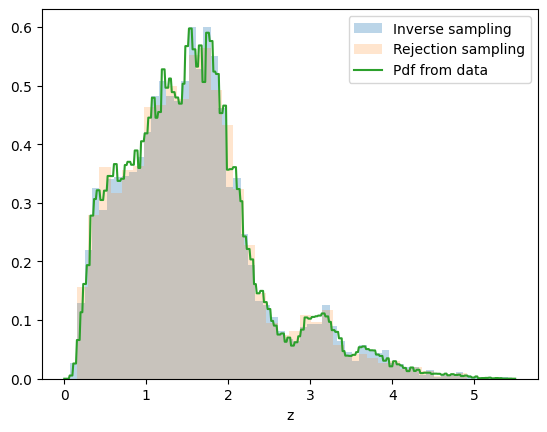

In [11]:
accepted_rate = (len(upsampled_data_inv)/N_sampled)*100
print(len(upsampled_data_inv))
print(f"Sono stati creati dati upsampled con una percentuale rispetto a N_Sampled di: {accepted_rate}%")

plt.hist(upsampled_data_inv, density = True, bins = 'auto', label = "Inverse sampling", alpha = 0.3);
plt.hist(upsampled_data_rej, density = True, bins = 'auto', label = "Rejection sampling", alpha = 0.2);
x = np.linspace(0, 5.5, 500)
plt.plot(x, pdf(x), label = "Pdf from data")
plt.legend()
plt.xlabel('z')
plt.savefig("./Images/EX_3_Upsampling.png")
plt.show()

Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

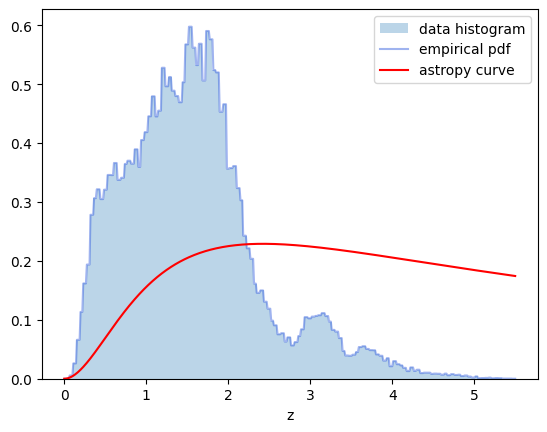

In [13]:
#usiamo il modulo di astropy
x = np.linspace(0, 5.5, 500)
dv_dz = astropy.cosmology.Planck18.differential_comoving_volume(x).value
dx = x[1] - x[0]
dv_dz_normalized = dv_dz / (np.sum(dv_dz) * dx)

plt.hist(z, density = True, bins = 'auto', alpha = 0.3, label = "data histogram");
plt.plot(x, pdf(x), color = 'royalblue', alpha = 0.5, label = "empirical pdf");
plt.plot(x, dv_dz_normalized, color = 'red', label = "astropy curve");
plt.legend()
plt.xlabel('z')
plt.savefig("./Images/EX_3_TheoreticalCurve.png")
plt.show()

La realtà fisica soffre degli effetti di selezione della strumentazione (a redshift piu' alti ho enormi distanze) 
La linea rossa è basata sull'assunto che i quasar siano distribuiti uniformemente nello spazio e fisso nel tempo, mentre i dati reali mostrano un'evoluzione in fasi dell'universo, partendo da z grandi dove era più giovane fino ad avvicinarsi a piccoli redshift.
La gobba a z ~ 3 è un artefatto strumentale.